In [1]:
#Cargue las librerías de TensorFlow y los métodos Datasets, layers, input, models de Keras. Además, matplotlib
# Cargar TensorFlow
import tensorflow as tf

# Cargar los métodos específicos de Keras
from tensorflow.keras import datasets, layers, models, Input

# Cargar matplotlib para visualización
import matplotlib.pyplot as plt

In [2]:
#Cargue el dataset de Keras CIFAR-10 y divídalo en imágenes de entrenamiento y pruebas
# Cargar el dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Verificar las dimensiones de los datos
print(f"Dimensiones de imágenes de entrenamiento: {x_train.shape}")
print(f"Dimensiones de etiquetas de entrenamiento: {y_train.shape}")
print(f"Dimensiones de imágenes de prueba: {x_test.shape}")
print(f"Dimensiones de etiquetas de prueba: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dimensiones de imágenes de entrenamiento: (50000, 32, 32, 3)
Dimensiones de etiquetas de entrenamiento: (50000, 1)
Dimensiones de imágenes de prueba: (10000, 32, 32, 3)
Dimensiones de etiquetas de prueba: (10000, 1)


In [ ]:
#Muestrame la cantidad de imagenes en x_train, x_test, y_train, y_test
# Mostrar la cantidad de imágenes
print(f"Cantidad de imágenes en x_train: {len(x_train)}")
print(f"Cantidad de imágenes en x_test: {len(x_test)}")
print(f"Cantidad de etiquetas en y_train: {len(y_train)}")
print(f"Cantidad de etiquetas en y_test: {len(y_test)}")

Cantidad de imágenes en x_train: 50000
Cantidad de imágenes en x_test: 10000
Cantidad de etiquetas en y_train: 50000
Cantidad de etiquetas en y_test: 10000


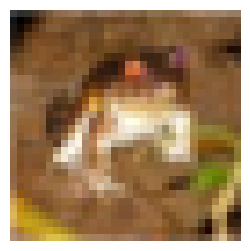

Primera etiqueta (valor numérico): 6
Nombre de la clase: 6


In [4]:
#Muestreme la primera imagen y la primera etiqueta
# Mostrar la primera imagen
plt.figure(figsize=(3, 3))
plt.imshow(x_train[0])
plt.axis('off')
plt.show()

# Mostrar la primera etiqueta
print(f"Primera etiqueta (valor numérico): {y_train[0][0]}")
print(f"Nombre de la clase: {y_train[0][0]}")

In [5]:
#Crear una lista llamada clases con avion, automovil, pajaro, gato, ciervo, perro, rana, caballo, barco y camion

# Crear la lista de clases
clases = ['avion', 'automovil', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']

# Mostrar la lista
print(clases)
print(f"Número de clases: {len(clases)}")

['avion', 'automovil', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']
Número de clases: 10


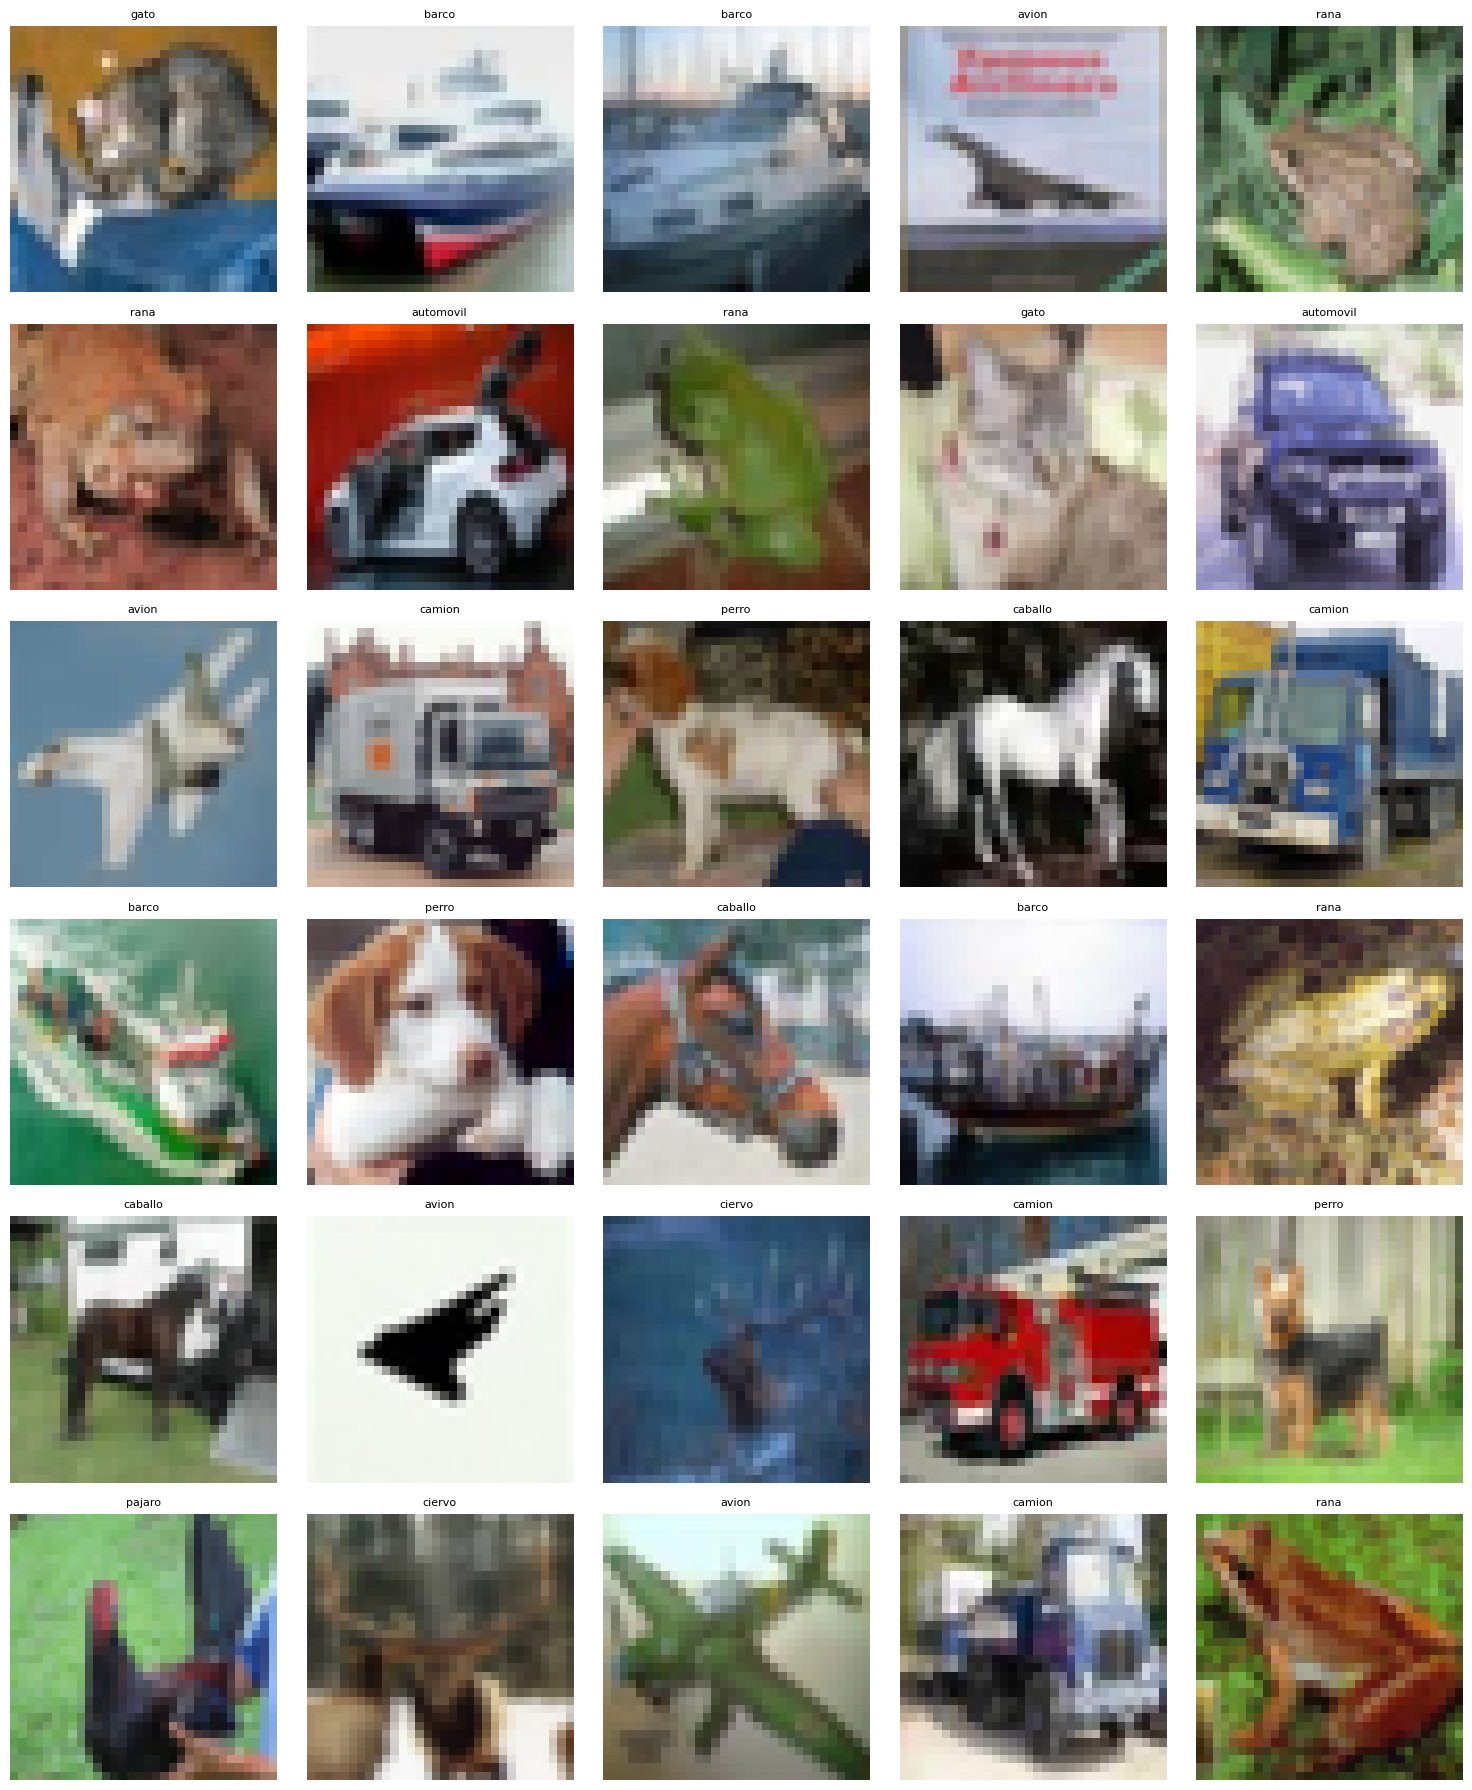

In [6]:
#Muestre las 30 primeras imagenes de x_test, colocando el valor equivalente a la clase con la variable que llamamos clase, el nombre de la clase coloquela en la parte superior, no coloca axis, organizalo de 5 columnas y 6 filas
# Mostrar las 30 primeras imágenes de x_test
plt.figure(figsize=(15, 18), dpi=100)

for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.imshow(x_test[i])
    plt.title(clases[y_test[i][0]], fontsize=8)
    plt.axis('off')
    
plt.tight_layout()
plt.show()


In [7]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [8]:
#Normalice las imagenes tanto de entrenamiento como de prueba dividiéndolas en 255
# Normalizar las imágenes de entrenamiento y prueba
x_train = x_train / 255.0
x_test = x_test / 255.0

# Verificar la normalización
print(f"Rango de valores en x_train: [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"Rango de valores en x_test: [{x_test.min():.2f}, {x_test.max():.2f}]")
print(f"Tipo de datos después de normalizar: {x_train.dtype}")

Rango de valores en x_train: [0.00, 1.00]
Rango de valores en x_test: [0.00, 1.00]
Tipo de datos después de normalizar: float64


In [9]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [10]:
# Crear una variable de numpy con y_train y encontrar valores únicos
import numpy as np

y_train_numpy = np.array(y_train)
valores_unicos = np.unique(y_train_numpy)

print("Valores únicos en y_train:")
print(valores_unicos)
print(f"Cantidad de valores únicos: {len(valores_unicos)}")

Valores únicos en y_train:
[0 1 2 3 4 5 6 7 8 9]
Cantidad de valores únicos: 10


# Construcción de mi primera Red Neuronal Convolucional

In [11]:
#Cree la parte convolucional de un modelo de deeplearning colocando el input por separado, cree dos capas convolucionales 2D de 64 y 32 unidades con Kernels de 3*3 utilizando función de activación RELU, con su respectiva capa de maxpooling de dimensión 2*2. Más adelante haremos la red neuronal
from tensorflow.keras import Model

# Definir la capa de entrada
input_layer = Input(shape=(32, 32, 3))

# Primera capa convolucional
conv1 = layers.Conv2D(64, (3, 3), activation='relu')(input_layer)
pool1 = layers.MaxPooling2D((2, 2))(conv1)

# Segunda capa convolucional
conv2 = layers.Conv2D(32, (3, 3), activation='relu')(pool1)
pool2 = layers.MaxPooling2D((2, 2))(conv2)

# Verificar la arquitectura hasta ahora
print("Arquitectura convolucional:")
print(f"Input shape: {input_layer.shape}")
print(f"Después de Conv2D(64): {conv1.shape}")
print(f"Después de MaxPooling2D: {pool1.shape}")
print(f"Después de Conv2D(32): {conv2.shape}")
print(f"Después de MaxPooling2D: {pool2.shape}")

# Agregar Flatten y capas densas
flatten = layers.Flatten()(pool2)
dense1 = layers.Dense(64, activation='relu')(flatten)
output_layer = layers.Dense(10, activation='softmax')(dense1)

model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

Arquitectura convolucional:
Input shape: (None, 32, 32, 3)
Después de Conv2D(64): (None, 30, 30, 64)
Después de MaxPooling2D: (None, 15, 15, 64)
Después de Conv2D(32): (None, 13, 13, 32)
Después de MaxPooling2D: (None, 6, 6, 32)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,698 (369.91 KB)

 Trainable params: 94,698 (369.91 KB)

 Non-trainable params: 0 (0.00 B)

# Definir la Red Neuronal

# Compilar y entrenar

In [12]:
#Compile el modelo utilizando Adam por defecto, utilice spacecategoricalcrossentropy, la métrica es accuracy, entrenemoslo con 30 épocas. Haga validación utilizando el 15% de los datos de entrenamiento

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo con 30 épocas y validación del 15%
history = model.fit(
    x_train, y_train,
    epochs=30,
    validation_split=0.15,
    batch_size=32,
    verbose=1
)

# Mostrar la precisión final
print("\n--- Resultados finales ---")
print(f"Precisión en entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Precisión en validación: {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/30
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4310 - loss: 1.5678 - val_accuracy: 0.5028 - val_loss: 1.3725
Epoch 2/30
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5537 - loss: 1.2507 - val_accuracy: 0.5689 - val_loss: 1.2274
Epoch 3/30
1051/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5946 - loss: 1.1451

KeyboardInterrupt: 

In [ ]:
#Grafiqueme el lost y el accuracy tanto de entrenamiento como de validación
# Graficar pérdida (loss) y precisión (accuracy)
plt.figure(figsize=(12, 4))

# Gráfico de pérdida (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Pérdida de validación', color='red', linewidth=2)
plt.title('Pérdida del modelo (Loss)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Gráfico de precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Precisión de validación', color='red', linewidth=2)
plt.title('Precisión del modelo (Accuracy)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar valores finales
print("="*50)
print("VALORES FINALES DESPUÉS DE 30 ÉPOCAS:")
print("="*50)
print(f"Pérdida de entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"Pérdida de validación: {history.history['val_loss'][-1]:.4f}")
print(f"Precisión de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"Precisión de validación: {history.history['val_accuracy'][-1]:.4f}")
print("="*50)

# Validemos el modelo con los datos de prueba

In [ ]:
#Use x_test y y_test con el modelo, saque la matriz de confusión con Seabornmap y las métricas de clasificación para validar el modelo

# Evaluar el modelo con los datos de prueba
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Pérdida en prueba: {test_loss:.4f}")
print(f"Precisión en prueba: {test_accuracy:.4f}")
print("="*50)

# Predecir las etiquetas para los datos de prueba
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calcular la matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_classes)

# Graficar la matriz de confusión con seaborn
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Confusión - CIFAR-10', fontsize=16)
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Mostrar métricas de clasificación
print("="*50)
print("MÉTRICAS DE CLASIFICACIÓN:")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=clases))

In [ ]:
#De esta imagen https://cdn.prod.website-files.com/64df6dd37ac6a0dbb9d03cb3/6597f2646581043618e42856_Instituto-Humboldt-rana-derecha.jpg aplique el modelo mostrando la etiqueta asignado y las probabilidades de que pertenezcan a las diferentes clases en la predicción

# Cargar la imagen desde la URL
import urllib.request
from PIL import Image

# URL de la imagen
url = "https://cdn.prod.website-files.com/64df6dd37ac6a0dbb9d03cb3/6597f2646581043618e42856_Instituto-Humboldt-rana-derecha.jpg"

# Descargar y cargar la imagen
urllib.request.urlretrieve(url, "imagen_rana.jpg")
img = Image.open("imagen_rana.jpg")

# Mostrar la imagen original
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Imagen original")
plt.axis('off')
plt.show()

# Preprocesar la imagen para el modelo
# Redimensionar a 32x32 píxeles (tamaño que espera el modelo)
img_resized = img.resize((32, 32))

# Convertir a array numpy y normalizar
img_array = np.array(img_resized) / 255.0

# El modelo espera un batch de imágenes, añadir dimensión de batch
img_array = np.expand_dims(img_array, axis=0)

# Verificar la forma
print(f"Forma de la imagen procesada: {img_array.shape}")

# Realizar la predicción
predicciones = model.predict(img_array)
prediccion_clase = np.argmax(predicciones[0])
probabilidades = predicciones[0]

# Mostrar resultados
print("\n" + "="*50)
print("RESULTADO DE LA PREDICCIÓN")
print("="*50)
print(f"Clase asignada: {prediccion_clase} - {clases[prediccion_clase]}")
print(f"Confianza: {probabilidades[prediccion_clase]:.4f} ({probabilidades[prediccion_clase]*100:.2f}%)")
print("\n" + "="*50)
print("PROBABILIDADES POR CLASE:")
print("="*50)

# Mostrar probabilidades para todas las clases
for i, clase in enumerate(clases):
    barra = "█" * int(probabilidades[i] * 50)
    print(f"{clase:<12}: {probabilidades[i]:.4f} ({probabilidades[i]*100:.2f}%) {barra}")

# Visualizar las probabilidades en una gráfica
plt.figure(figsize=(10, 6))
plt.barh(clases, probabilidades, color='skyblue')
plt.xlabel('Probabilidad')
plt.title('Probabilidades de predicción por clase')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar la imagen procesada que se usó para la predicción
plt.figure(figsize=(4, 4))
plt.imshow(img_array[0])
plt.title(f"Predicción: {clases[prediccion_clase]} ({probabilidades[prediccion_clase]*100:.1f}%)")
plt.axis('off')
plt.show()

In [ ]:
#Guarda el modelo en formato KERAS llamandolo detector.keras
# Guardar el modelo en formato KERAS
model.save('detector.keras')

# Verificar que se guardó correctamente
import os
if os.path.exists('detector.keras'):
    tamanio = os.path.getsize('detector.keras') / (1024 * 1024)  # Tamaño en MB
    print(f"Modelo guardado exitosamente como 'detector.keras'")
    print(f"Tamaño del archivo: {tamanio:.2f} MB")
else:
    print("Error al guardar el modelo")

In [ ]:
#Mirar versión de TensorFlow y Keras

# Creeme una aplicación en StreamLit que me permita cargar una imagen en formato .jpg o .png desde una URL o desde mi escritorio, o tomar una foto desde mi camara, y aplique el modelo detector.keras que fue entrenado. La imagen tiene que redimensionarse a 32*32 a color y normalizar dividiendo por 255 antes de hacer la predicción. Además, coloque títulos y textos y finalmente mostrar cuál es la clase a la que pertenece utilizando clases = ['avion', 'automovil', 'pajaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion'] y muestremé la probabilidad